# `dp_check` — Figure-3 multimodality check on the **official** Diffusion Policy

Loads the **authors' fully-trained** image-PushT checkpoint (`diffusion_policy_cnn`, `train_0`,
`epoch=0500-test_mean_score=0.884` — the model behind the paper's Table I / Fig 3) and, at a
**designated start state**, samples K single action-chunks varying only the denoising noise, then measures
multimodality at the **trajectory level**.

**Metric (trajectory-level, not endpoints):** each chunk is a full `horizon`-step curve. We compare curves
by **aligned-RMSE** (`d(i,j)=sqrt(mean_t ||X_i[t]-X_j[t]||^2)`, exact here since chunks are same-length &
time-aligned = Euclidean in the flattened `2*horizon`-D space), take the leading **PCA coordinate `PC1`**
(the axis of maximum spread), and run **Hartigan's dip test** on it. **Verdict = dip p-value:** `p<0.05`
rejects unimodality -> the chunk set is genuinely multimodal. (Endpoint-only heading would miss curves that
bow opposite ways but end near the same point.)

Mirrors `debug_latent_sde_pusht.ipynb`, but uses the **DP repo's own** policy + `PushTImageEnv`.

> **Kernel:** select **`Python (robodiff)`**. Runs on GPU0.

In [1]:
%matplotlib inline
import os, sys, math
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # headless pygame (offscreen surface)
DP_REPO = "/tmp/diffusion_policy"
sys.path.insert(0, DP_REPO)
os.chdir(DP_REPO)                                    # cfg uses repo-relative paths

import numpy as np, torch, dill, hydra, diptest
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from diffusion_policy.env.pusht.pusht_image_env import PushTImageEnv
from diffusion_policy.env.pusht.pusht_env import PushTEnv

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- pick the checkpoint (swap to compare runs) -------------------------------------------------
CKPT = "/tmp/dp_upstream/official/official_train0_ep500_0.884.ckpt"   # authors' fully-trained (0.884)
# CKPT = "/tmp/dp_upstream/out/checkpoints/epoch=0100-test_mean_score=0.767.ckpt"  # our partial retrain
print("checkpoint:", CKPT)

/home/v-hihwang/miniforge3/envs/robodiff/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pygame 2.1.2 (SDL 2.0.16, Python 3.9.18)
Hello from the pygame community. https://www.pygame.org/contribute.html


checkpoint: /tmp/dp_upstream/official/official_train0_ep500_0.884.ckpt


In [2]:
# --- load the DP-repo checkpoint -> EMA policy (mirrors eval.py) ---------------------------------
payload = torch.load(open(CKPT, "rb"), pickle_module=dill, map_location="cpu")
cfg = payload["cfg"]
cls = hydra.utils.get_class(cfg._target_)
ws  = cls(cfg, output_dir="/tmp/dp_check_ws")
ws.load_payload(payload, exclude_keys=None, include_keys=None)
policy = ws.ema_model if cfg.training.use_ema else ws.model     # eval uses EMA weights
policy.to(device).eval()
n_obs, H, n_act = policy.n_obs_steps, policy.horizon, policy.n_action_steps
print(f"loaded: use_ema={cfg.training.use_ema}  n_obs={n_obs}  horizon={H}  n_action_steps={n_act}  "
      f"num_inference_steps={policy.num_inference_steps}")

/home/v-hihwang/miniforge3/envs/robodiff/lib/python3.9/site-packages/wandb/apis/public.py:2997: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


/home/v-hihwang/miniforge3/envs/robodiff/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []


/home/v-hihwang/miniforge3/envs/robodiff/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/home/v-hihwang/miniforge3/envs/robodiff/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Diffusion params: 2.515119e+08
Vision params: 1.119709e+07


loaded: use_ema=True  n_obs=2  horizon=16  n_action_steps=8  num_inference_steps=100


In [3]:
# --- envs + state helpers -----------------------------------------------------------------------
obs_env  = PushTImageEnv(legacy=True, render_size=96)
disp_env = PushTEnv(legacy=True, render_size=512, render_action=False)
obs_env.reset_to_state = None; obs_env.reset()          # instantiate block -> read its CoG offset
BLOCK_COG = np.array(obs_env.block.center_of_gravity, dtype=np.float64)   # ~[0,45]; T spins about CoG
print("BLOCK_COG:", BLOCK_COG)

def get_obs(state5):
    obs_env.reset_to_state = np.asarray(state5, dtype=np.float64).copy()
    return obs_env.reset()

def render512(state5):
    disp_env.reset_to_state = np.asarray(state5, dtype=np.float64).copy(); disp_env.reset()
    return disp_env.render("rgb_array")

BLOCK_COG: [ 0. 45.]


## Trajectory-level multimodality: aligned-RMSE + dip test
`traj_multimodality(plans)` takes K time-aligned curves `(K, T, 2)`, computes the aligned-RMSE pairwise
distances (= Euclidean in the flattened curve space), extracts the leading **PCA coordinate `PC1`** (axis of
max spread), and returns the **Hartigan dip-test p-value** (H0: unimodal). `multimodal = (p < 0.05)`.

In [4]:
def traj_multimodality(plans):
    """plans: (K, T, 2) time-aligned trajectories.
    aligned-RMSE pairwise distance = Euclidean in the flattened 2T-D curve space;
    unimodality tested with Hartigan's dip test on the leading PCA coordinate (PC1)."""
    K, T, _ = plans.shape
    X  = plans.reshape(K, -1).astype(np.float64)              # (K, 2T) flattened curves
    Xc = X - X.mean(0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)         # PCA of the flattened curves
    pc1 = Xc @ Vt[0]                                          # (K,) axis of max spread
    pc2 = Xc @ Vt[1] if len(S) > 1 else np.zeros(K)
    dip, p = diptest.diptest(np.ascontiguousarray(pc1))
    rmse = pdist(X) / np.sqrt(T)                              # full-curve aligned-RMSE (px), for context
    return dict(pc1=pc1, pc2=pc2, dip=float(dip), pval=float(p),
                mean_rmse=float(rmse.mean()), max_rmse=float(rmse.max()),
                multimodal=bool(p < 0.05))

@torch.no_grad()
def sample_chunks(state5, K=24, seed=0):
    """K predicted horizon action-chunks (absolute agent targets, world px) from the SAME frozen frame,
    varying only the denoising noise. Returns (K, H, 2)."""
    obs = get_obs(state5)
    img = torch.from_numpy(obs["image"]).float()
    ap  = torch.from_numpy(np.asarray(obs["agent_pos"])).float()
    obs_dict = {"image":     img[None,None].repeat(K, n_obs, 1, 1, 1).to(device),
                "agent_pos": ap[None,None].repeat(K, n_obs, 1).to(device)}
    torch.manual_seed(seed)
    return policy.predict_action(obs_dict)["action_pred"].cpu().numpy()

def plans_at_state(state5, K=24, seed=0):
    """K predicted chunks at state5 (K,H,2) + the display frame — mirrors debug_latent_sde_pusht.ipynb."""
    return sample_chunks(state5, K=K, seed=seed), render512(state5)

## Designated start state
Edit `PEG_XY` / `BLOCK_CENTER` / `BLOCK_ANGLE` (world px in `[0,512]`, angle in radians). Default = the
reproduced Fig-3 decision point from `debug_latent_sde_pusht.ipynb` §2.

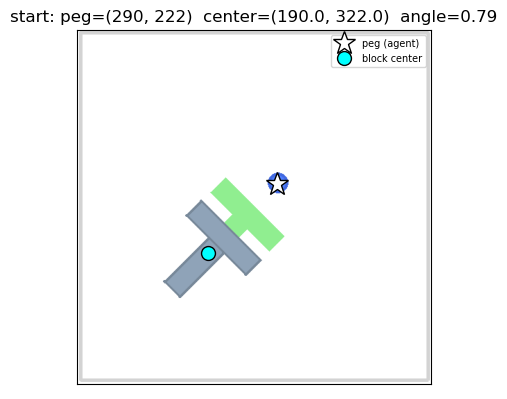

In [5]:
PEG_XY       = (290.0, 222.0)
BLOCK_CENTER = (190.0, 322.0)
BLOCK_ANGLE  = math.pi / 4

block_origin = np.array(BLOCK_CENTER, dtype=np.float64) - BLOCK_COG
state5 = np.array([PEG_XY[0], PEG_XY[1], block_origin[0], block_origin[1], BLOCK_ANGLE])

_obs = get_obs(state5)
plt.figure(figsize=(4.6, 4.6)); plt.imshow(render512(state5), extent=[0, 512, 512, 0])
plt.plot(*_obs["agent_pos"], "*", color="white", ms=17, mec="k", mew=1.0, label="peg (agent)")
plt.plot(*BLOCK_CENTER, "o", color="cyan", ms=10, mec="k", mew=1.0, label="block center")
plt.title(f"start: peg={tuple(np.round(_obs['agent_pos']).astype(int))}  center={BLOCK_CENTER}  angle={BLOCK_ANGLE:.2f}")
plt.xlim(0,512); plt.ylim(512,0); plt.xticks([]); plt.yticks([]); plt.legend(fontsize=7); plt.show()

## Sample K chunks + measure
Left: the K predicted chunks over the frame, colored by their `PC1` score (the multimodality axis).
Right: the **PCA scatter** (each curve = one point; one blob = unimodal, two clusters = real modes).
Verdict from the dip test.

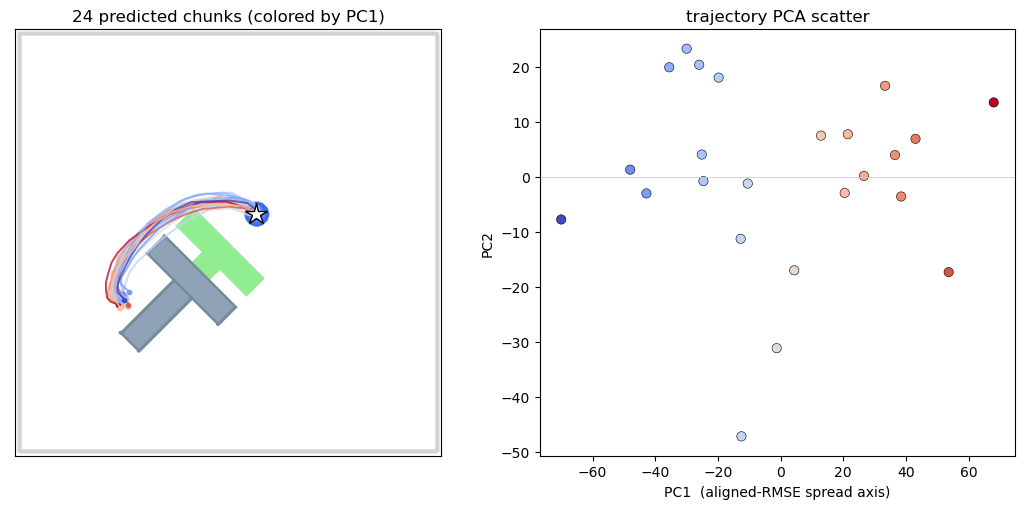

aligned-RMSE: mean 14.2px  max 35.2px  | dip stat 0.0579  p-value 0.7778
>>> VERDICT at this state: unimodal (p>=0.05)


In [6]:
K = 24
chunks = sample_chunks(state5, K=K, seed=0)          # (K, H, 2)
st = traj_multimodality(chunks)
frame = render512(state5)

# color by PC1 (diverging), so the coloring reflects the trajectory-level spread axis
pc1 = st["pc1"]; s = np.max(np.abs(pc1)) + 1e-9
cmap = plt.get_cmap("coolwarm"); colf = lambda v: cmap(0.5 + 0.5*v/s)

fig, ax = plt.subplots(1, 2, figsize=(10.6, 5.2))
ax[0].imshow(frame, extent=[0,512,512,0])
for k in range(K):
    c = chunks[k]; ax[0].plot(c[:,0], c[:,1], "-", color=colf(pc1[k]), lw=1.4, alpha=0.8)
    ax[0].plot(c[-1,0], c[-1,1], ".", color=colf(pc1[k]), ms=6)
ax[0].plot(*get_obs(state5)["agent_pos"], "*", color="white", ms=16, mec="k", mew=1.0)
ax[0].set_title(f"{K} predicted chunks (colored by PC1)"); ax[0].set_xlim(0,512); ax[0].set_ylim(512,0)
ax[0].set_xticks([]); ax[0].set_yticks([])
ax[1].scatter(st["pc1"], st["pc2"], c=st["pc1"], cmap="coolwarm", s=45, edgecolor="k", lw=0.4)
ax[1].set_xlabel("PC1  (aligned-RMSE spread axis)"); ax[1].set_ylabel("PC2")
ax[1].set_title("trajectory PCA scatter"); ax[1].axhline(0, color="#ccc", lw=0.6)
plt.tight_layout(); plt.show()

print(f"aligned-RMSE: mean {st['mean_rmse']:.1f}px  max {st['max_rmse']:.1f}px  "
      f"| dip stat {st['dip']:.4f}  p-value {st['pval']:.4f}")
print(f">>> VERDICT at this state: {'MULTIMODAL (p<0.05)' if st['multimodal'] else 'unimodal (p>=0.05)'}")

## Open-loop rollout of a few chunks
Execute several chunks open-loop from the start state; overlay realized agent paths (colored by PC1) and
report max-coverage reward. Unimodal -> paths coincide; multimodal -> they diverge.

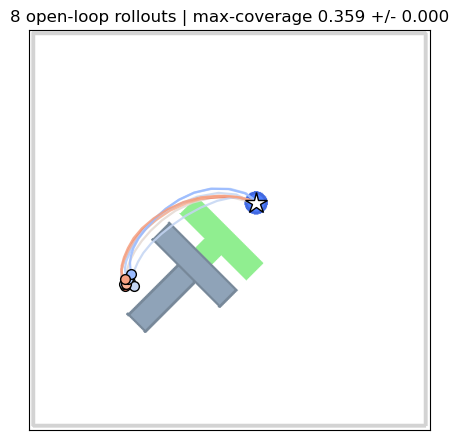

per-rollout max-coverage reward: [0.359, 0.359, 0.359, 0.359, 0.359, 0.359, 0.359, 0.359]


In [7]:
def rollout_openloop(state5, chunk):
    env = PushTImageEnv(legacy=True, render_size=96)
    env.reset_to_state = np.asarray(state5, np.float64).copy(); env.reset()
    traj = [np.array(env.agent.position, np.float64)]; rew = []
    for a in chunk[n_obs-1:]:
        obs, r, done, info = env.step(np.asarray(a, np.float64))
        traj.append(np.array(env.agent.position, np.float64)); rew.append(float(r))
        if done: break
    return np.array(traj), (max(rew) if rew else 0.0)

M = min(8, K)
plt.figure(figsize=(5.2, 5.2)); plt.imshow(render512(state5), extent=[0,512,512,0])
covs = []
for k in range(M):
    traj, cov = rollout_openloop(state5, chunks[k]); covs.append(cov)
    plt.plot(traj[:,0], traj[:,1], "-", color=colf(pc1[k]), lw=1.6, alpha=0.85)
    plt.plot(traj[-1,0], traj[-1,1], "o", color=colf(pc1[k]), ms=7, mec="k")
plt.plot(*get_obs(state5)["agent_pos"], "*", color="white", ms=16, mec="k", mew=1.0)
plt.title(f"{M} open-loop rollouts | max-coverage {np.mean(covs):.3f} +/- {np.std(covs):.3f}")
plt.xlim(0,512); plt.ylim(512,0); plt.xticks([]); plt.yticks([]); plt.show()
print("per-rollout max-coverage reward:", [round(c,3) for c in covs])

## Scan: how often is the official model multimodal?
Sweep N random start states; at each, sample K chunks and apply the dip test. Panels: (1) dip-p histogram,
(2) the **most-multimodal** state's chunks colored by PC1, (3) that state's **PCA scatter**. Mirrors the §4
scan in `debug_latent_sde_pusht.ipynb`.

official DP: 120 random states -> dip-multimodal (p<0.05) 6/120 (5.0%) | median dip p 0.698
top-5 most-multimodal states (smallest dip p; plug state5 into the designated-state cell):
  p=0.0000  dip=0.1602  mean_rmse= 69.7px  state5=[207.0, 288.0, 354.0, 196.0, 6.0]
  p=0.0032  dip=0.1309  mean_rmse= 40.3px  state5=[213.0, 419.0, 229.0, 252.0, 6.0]
  p=0.0034  dip=0.1302  mean_rmse= 62.4px  state5=[277.0, 176.0, 228.0, 170.0, 1.5]
  p=0.0042  dip=0.1285  mean_rmse= 69.1px  state5=[213.0, 164.0, 294.0, 164.0, 6.2]
  p=0.0061  dip=0.1253  mean_rmse= 71.8px  state5=[97.0, 309.0, 396.0, 232.0, 2.0]


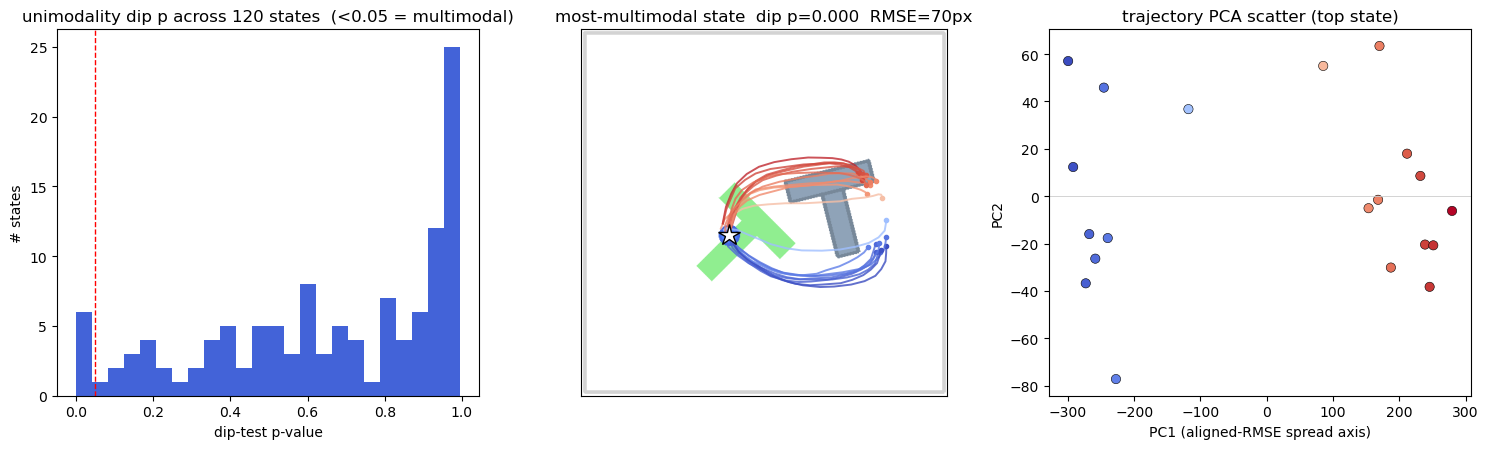

In [8]:
N_SCAN, Ks, ALPHA = 120, 20, 0.05

rng = np.random.RandomState(100000)   # same seed family as debug_latent_sde_pusht.ipynb
rows = []
for i in range(N_SCAN):
    s = np.array([rng.randint(60,452), rng.randint(60,452),
                  rng.randint(110,402), rng.randint(110,402), rng.uniform(0, 2*np.pi)], np.float64)
    plans, render = plans_at_state(s, K=Ks)
    st = traj_multimodality(plans)
    rows.append({"state5": s, "plans": plans, "render": render, **st})

pvals = np.array([r["pval"] for r in rows]); hits = int((pvals < ALPHA).sum())
print(f"official DP: {N_SCAN} random states -> dip-multimodal (p<{ALPHA}) {hits}/{N_SCAN} "
      f"({100*hits/N_SCAN:.1f}%) | median dip p {np.median(pvals):.3f}")
rows.sort(key=lambda r: r["pval"])   # smallest p = strongest multimodality
print("top-5 most-multimodal states (smallest dip p; plug state5 into the designated-state cell):")
for r in rows[:5]:
    print(f"  p={r['pval']:.4f}  dip={r['dip']:.4f}  mean_rmse={r['mean_rmse']:5.1f}px  "
          f"state5={np.round(r['state5'],1).tolist()}")

top = rows[0]; pc1 = top["pc1"]; sc = np.max(np.abs(pc1)) + 1e-9
cmap = plt.get_cmap("coolwarm"); colf = lambda v: cmap(0.5 + 0.5*v/sc)   # color by PC1 (spread axis)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
ax[0].hist(pvals, bins=24, color="#4363d8"); ax[0].axvline(ALPHA, color="r", ls="--", lw=1)
ax[0].set_xlabel("dip-test p-value"); ax[0].set_ylabel("# states")
ax[0].set_title(f"unimodality dip p across {N_SCAN} states  (<{ALPHA} = multimodal)")
ax[1].imshow(top["render"], extent=[0,512,512,0])
for k in range(len(top["plans"])):
    c = top["plans"][k]; ax[1].plot(c[:,0], c[:,1], "-", color=colf(pc1[k]), lw=1.4, alpha=0.8)
    ax[1].plot(c[-1,0], c[-1,1], ".", color=colf(pc1[k]), ms=6)
ax[1].plot(top["state5"][0], top["state5"][1], "*", color="white", ms=16, mec="k", mew=1.0)
ax[1].set_xlim(0,512); ax[1].set_ylim(512,0); ax[1].set_xticks([]); ax[1].set_yticks([])
ax[1].set_title(f"most-multimodal state  dip p={top['pval']:.3f}  RMSE={top['mean_rmse']:.0f}px")
ax[2].scatter(top["pc1"], top["pc2"], c=top["pc1"], cmap="coolwarm", s=45, edgecolor="k", lw=0.4)
ax[2].axhline(0, color="#ccc", lw=0.6); ax[2].set_xlabel("PC1 (aligned-RMSE spread axis)")
ax[2].set_ylabel("PC2"); ax[2].set_title("trajectory PCA scatter (top state)")
plt.tight_layout(); plt.show()